In [2]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
from val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'torchmetrics'

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

In [5]:
def load_datasets(filepath):
    """Carrega os datasets de arquivos pickle."""
    try:
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        return dataset
    except IOError as e:
        log.error(f"Erro ao carregar o dataset: {e}")
    except pickle.PickleError as e:
        log.error(f"Erro ao desserializar o dataset: {e}")
        traceback.print_exception(e)

In [6]:
from chronos import ChronosPipeline

## Data

In [7]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


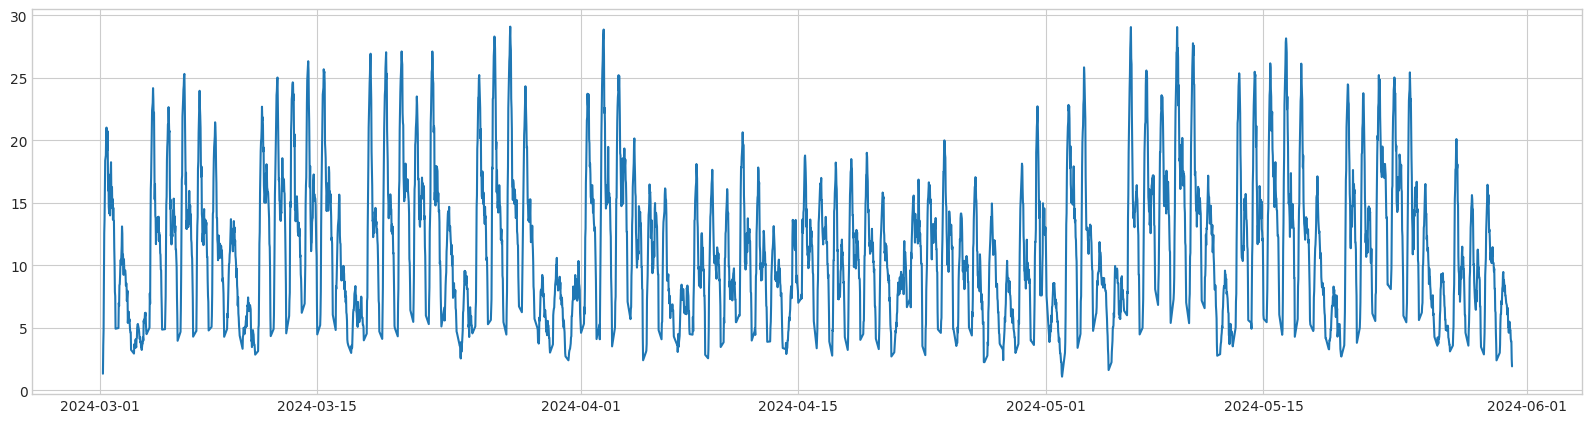

In [8]:
plt.figure(figsize=(20, 5))
plt.plot(sb["125960550"])
plt.show()

## Model

In [14]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cuda",  # use "cpu" for CPU inference and "mps" for Apple Silicon
    torch_dtype=torch.bfloat16,
)

## Data

In [15]:
# define X and Y
sbx = sb.query("index <= '2024-04-30 23:59:59'")
sbx.shape, sb.shape

((2438, 10), (3640, 10))

In [16]:
# define X and Y
sby = sb.query("index > '2024-04-30 23:59:59'")
sby.shape, sb.shape

((1202, 10), (3640, 10))

In [17]:
pred_len = abs(sbx.shape[0] - sb.shape[0])
pred_len

1202

In [18]:
sbx

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609
...,...,...,...,...,...,...,...,...,...,...
2024-04-30 21:30:00,13.068083,42.286766,1535.981445,2419.440186,153.250549,235.504761,534.730774,360.065674,70.640297,196.380493
2024-04-30 22:00:00,12.431416,36.383987,1481.968506,2273.043945,140.052750,213.457916,497.275299,345.012817,61.992599,188.921158
2024-04-30 22:30:00,12.874792,30.133987,1384.169556,2076.893555,114.104424,199.529144,446.210358,313.378143,49.574951,168.745636
2024-04-30 23:00:00,13.041458,20.388889,1265.604004,1824.310059,109.278534,175.532318,392.957520,282.470123,45.148010,150.670944


### Inference

In [19]:
forecast = pipeline.predict(context=torch.tensor(sbx["125960550"]),
                            prediction_length=pred_len,
                            limit_prediction_length=False,
                            num_samples=1)

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


In [20]:
y_hat = forecast.view(-1)
y_pred =  y_hat.cpu().data.numpy()
y_pred.shape

(1202,)

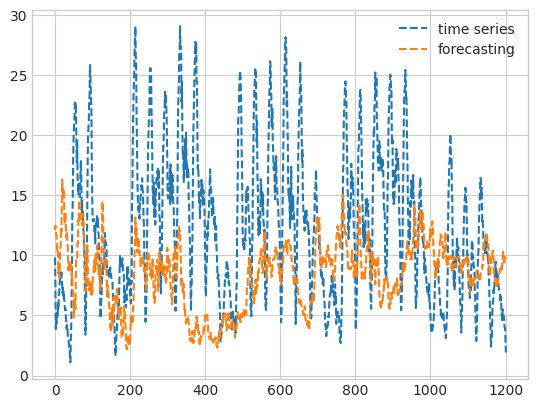

In [21]:
# only focasting
plt.plot(sby["125960550"].values, '--', label="time series")
plt.plot(y_pred, '--', label="forecasting")
plt.legend()
plt.show()

In [22]:
len_fore = y_pred.shape[0]

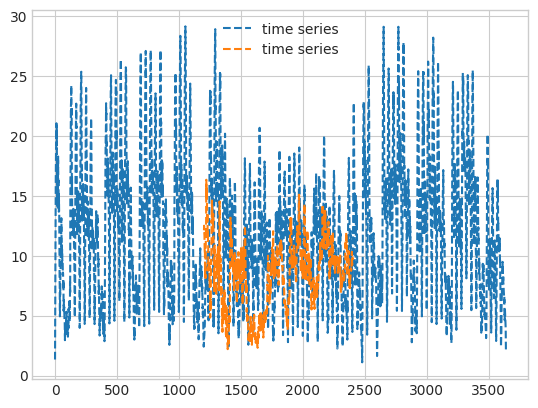

In [23]:
# only focasting
plt.plot(np.arange(0, len(sb["125960550"])), sb["125960550"], '--', label="time series")
plt.plot(np.arange(len_fore, len_fore + len(y_pred)), y_pred, '--', label="time series")
#plt.plot(y_pred, '--', label="forecasting")
plt.legend()
plt.show()

In [3]:
results = pd.read_parquet("CRHONOS-short-time.parquet")
results.head()

,node,mae,mse,r2,mape,model
0,125960550,6.160245,6.189288e+01,-0.657321,0.536559,cronos-BASE
1,230565994,14.334797,3.865694e+02,-0.601121,1.046061,cronos-BASE
2,258781031,314.608093,1.733610e+05,0.266102,0.425684,cronos-BASE
3,43768720,944.357971,1.314671e+06,-0.760015,0.839489,cronos-BASE
4,44072192,56.759014,4.519636e+03,-0.227434,0.803945,cronos-BASE


In [4]:
results["mae"].mean()

186.85472803115846

In [5]:
results["mse"].mean()

160742.8852657318

In [6]:
results["r2"].mean()

-0.49635141491889956

In [7]:
results["mape"].mean()

0.8311403691768646